<a href="https://colab.research.google.com/github/BrajanNieto/RiskAnalysis/blob/main/MonteCarloExample-BrajanNieto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Monte Carlo Simulation for Project Risk Management**


---



Description:

This Python script implements a Monte Carlo simulation for project risk management. It helps in estimating project contingencies by modeling uncertain parameters (such as cost, time, and resources) and running multiple simulations to predict possible outcomes. The tool also generates graphs to visualize the probability distribution of the results, helping decision-makers better understand potential risks and plan accordingly.

Key features:

    Monte Carlo Simulation: Simulates different scenarios based on uncertain project parameters.
    Contingency Calculation: Estimates the required contingency based on the distribution of possible outcomes.
    Visualization: Generates histograms and cumulative probability plots for clear result interpretation.

Output:

    A list of possible project costs or durations.
    Estimated contingency percentage based on risk tolerance.
    Visual representations of the simulation results (e.g., histograms, cumulative probability charts).

**Author:**  
Nieto Espinoza, Brajan E.  
[brajan.nieto@utec.edu.pe](mailto:brajan.nieto@utec.edu.pe)


---



In [7]:
#Libraries
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# =========================================================
# Función para simular una sola actividad con distribución PERT
# =========================================================
def pert_simulation(optimistic, most_probable, pessimistic, n_simulations):
    """
    Genera simulaciones de costo para una actividad usando una aproximación
    de la distribución PERT basada en una distribución normal, tomando:
      - La media como (optimistic + 4*most_probable + pessimistic)/6
      - La desviación estándar como (pessimistic - optimistic)/6

    Retorna un array de numpy con n_simulations valores simulados.
    """
    # Cálculo de la media y la desviación estándar (PERT aproximado con normal)
    expected_cost = (optimistic + 4 * most_probable + pessimistic) / 6
    std_dev = (pessimistic - optimistic) / 6

    # Generar muestras de una distribución normal
    simulated_costs = np.random.normal(expected_cost, std_dev, n_simulations)
    return simulated_costs

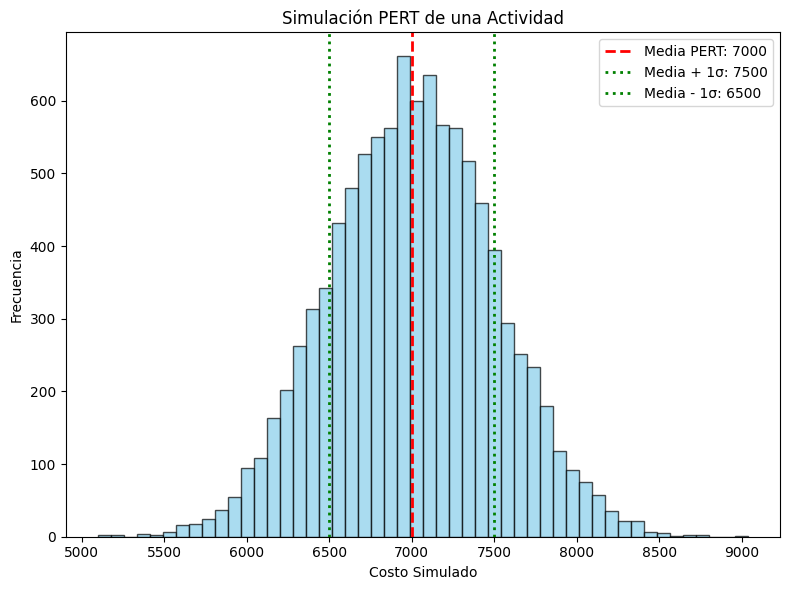

In [9]:
# =========================================================
# Ejemplo de uso de la función `pert_simulation` y visualización
# =========================================================
if __name__ == "__main__":
    # Parámetros de la actividad para la simulación
    optimistic = 5500
    most_probable = 7000
    pessimistic = 8500
    n_simulations = 10000 # Número de simulaciones a realizar

    # Realizar la simulación
    simulated_costs = pert_simulation(optimistic, most_probable, pessimistic, n_simulations)

    # Calcular la media y la desviación estándar basada en PERT para referencia
    expected_cost = (optimistic + 4 * most_probable + pessimistic) / 6
    std_dev = (pessimistic - optimistic) / 6

    # Generar un histograma para visualizar la distribución de los costos simulados
    plt.figure(figsize=(8, 6))
    plt.hist(simulated_costs, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title('Simulación PERT de una Actividad')
    plt.xlabel('Costo Simulado')
    plt.ylabel('Frecuencia')

    # Añadir líneas verticales para la media esperada y ±1 desviación estándar
    plt.axvline(expected_cost, color='red', linestyle='--', linewidth=2, label=f'Media PERT: {expected_cost:.0f}')
    plt.axvline(expected_cost + std_dev, color='green', linestyle=':', linewidth=2, label=f'Media + 1σ: {expected_cost + std_dev:.0f}')
    plt.axvline(expected_cost - std_dev, color='green', linestyle=':', linewidth=2, label=f'Media - 1σ: {expected_cost - std_dev:.0f}')

    plt.legend()
    plt.tight_layout()
    plt.show()

In [10]:
# =========================================================
# Función para calcular un percentil dado de los resultados
# =========================================================
def calculate_percentile(results, percentile=90):
    """
    Retorna el valor en 'results' correspondiente al percentile dado.
    Por ejemplo, percentile=90 -> P90.
    """
    return np.percentile(results, percentile)

In [11]:
# =========================================================
# Function to plot the histogram of total costs
# with shading for the confidence interval
# =========================================================
def plot_total_distribution(total_costs, confidence=0.90, simple_sum=None):
    """
    Generates a histogram of the total cost distribution and displays:
      - The confidence interval (CI) up to the specified percentile (e.g., 90%) shaded.
      - A vertical line indicating the "simple sum" (optional).
    """
    plt.figure(figsize=(8, 6))

    # Main histogram
    counts, bins, patches = plt.hist(total_costs, bins=50, color='blue', alpha=0.7, edgecolor='black')

    # Calculate upper bound for the CI at the desired percentile (e.g., 90th percentile)
    lower_bound = np.min(total_costs)  # starting from the minimum value
    upper_bound = np.percentile(total_costs, confidence * 100)  # 90th percentile

    # Shade the interval from the minimum up to the upper_bound
    plt.axvspan(lower_bound, upper_bound, color='orange', alpha=0.2, label=f'CI up to {int(confidence*100)}th percentile')

    # Vertical line for the simple sum of the means (optional)
    if simple_sum is not None:
        plt.axvline(simple_sum, color='red', linestyle='--', linewidth=2,
                    label=f'Simple Sum of Means: {simple_sum:,.0f}')

    # Add labels and legend
    plt.title('Total Project Cost Distribution')
    plt.xlabel('Cost')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [12]:
# =========================================================
# Función para graficar la distribución de cada actividad en subplots
# =========================================================
def plot_activity_distributions(all_activities_costs, activities):
    """
    Muestra un conjunto de subplots (2 x 5 si hay 10 actividades)
    con la distribución individual de cada actividad.
    """
    n_activities = len(activities)
    cols = 5
    rows = (n_activities + cols - 1) // cols  # Calcular filas necesarias

    plt.figure(figsize=(cols*4, rows*3))

    for i in range(n_activities):
        plt.subplot(rows, cols, i+1)
        plt.hist(all_activities_costs[i], bins=30, color='green', alpha=0.7, edgecolor='black')

        # Calculamos la media PERT para mostrarla con una línea vertical
        optimistic = activities[i]["optimistic"]
        most_probable = activities[i]["most_probable"]
        pessimistic = activities[i]["pessimistic"]
        mean_pert = (optimistic + 4*most_probable + pessimistic) / 6

        plt.axvline(mean_pert, color='red', linestyle='--', linewidth=2,
                    label=f'Media PERT={mean_pert:.0f}')

        plt.title(f'{activities[i]["name"]}')
        plt.xlabel('Costo')
        plt.ylabel('Frecuencia')
        plt.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

# Project Overview

This project focuses on estimating the total cost of a project with 10 activities using Monte Carlo simulation based on the PERT distribution. Each activity is defined by three cost estimates: Optimistic, Most Probable, and Pessimistic. The main steps include:

1. **Activity Cost Simulation**:  
   For each activity, 10,000 simulations are run using a PERT approximation (modeled as a normal distribution) to generate a range of possible costs, capturing uncertainty.

2. **Visualization of Individual Activities**:  
   Histograms for each activity's simulated costs are created, showing their respective distributions and highlighting the PERT mean as a reference.

3. **Total Project Cost Calculation**:  
   - The total project cost for each simulation run is obtained by summing the simulated costs of all activities.
   - A "simple sum" of the PERT means of all activities is computed as a baseline deterministic estimate.

4. **Statistical Analysis**:  
   Key percentiles (P10, P50, P90) of the total project cost distribution are calculated:
   - **P90** is used as a contingency value, indicating there is a 90% probability that the project cost will not exceed this value.

5. **Total Cost Visualization**:  
   A histogram of the total project cost is plotted:
   - An interval (e.g., a 90% confidence interval) is highlighted.
   - A vertical line marks the simple sum of the means for comparison.

**Objective**:  
The goal is to provide a robust estimate of the project's total cost by considering uncertainty in each activity. Using Monte Carlo simulation and PERT, the analysis yields a probability distribution of possible total costs, aiding in better financial planning and risk management.


In [ ]:
# Semilla para reproducibilidad (opcional)
np.random.seed(12345)

# Definir el número de simulaciones
n_simulations = 10000

# Lista de actividades con (Optimistic, Most Probable, Pessimistic)
activities = [
        {"name": "Activity 1",  "optimistic": 6500, "most_probable": 7000, "pessimistic": 8000},
        {"name": "Activity 2",  "optimistic": 4000, "most_probable": 5000, "pessimistic": 7000},
        {"name": "Activity 3",  "optimistic": 3000, "most_probable": 3500, "pessimistic": 4000},
        {"name": "Activity 4",  "optimistic": 5000, "most_probable": 6000, "pessimistic": 6500},
        {"name": "Activity 5",  "optimistic": 3500, "most_probable": 5000, "pessimistic": 5500},
        {"name": "Activity 6",  "optimistic": 4500, "most_probable": 6500, "pessimistic": 7000},
        {"name": "Activity 7",  "optimistic": 2500, "most_probable": 4000, "pessimistic": 5000},
        {"name": "Activity 8",  "optimistic": 1500, "most_probable": 3000, "pessimistic": 3500},
        {"name": "Activity 9",  "optimistic": 7000, "most_probable": 8000, "pessimistic": 8500},
        {"name": "Activity 10", "optimistic": 7500, "most_probable": 9500, "pessimistic": 9800},
]

In [ ]:
# =========================================================
# 1) Simular costos para cada actividad y guardar resultados
# =========================================================
all_activities_costs = []  # Aquí guardamos array de costos para cada actividad
for activity in activities:
    costs = pert_simulation(
        activity["optimistic"],
        activity["most_probable"],
        activity["pessimistic"],
        n_simulations
    )
    all_activities_costs.append(costs)

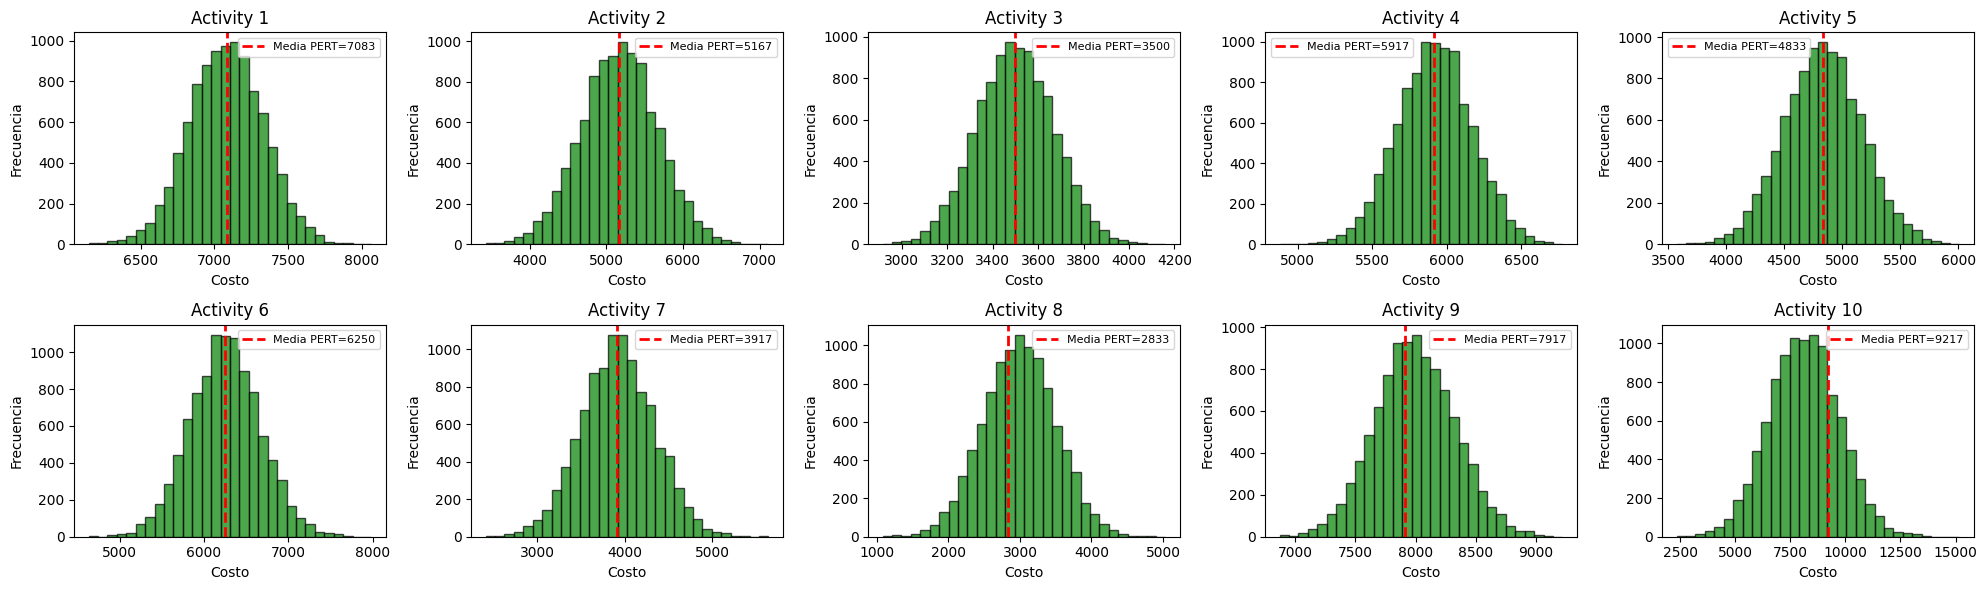

In [ ]:
# =========================================================
# 2) Graficar la distribución de cada actividad (subplots)
# =========================================================
plot_activity_distributions(all_activities_costs, activities)

In [ ]:
# =========================================================
# 3) Obtener la distribución de costos totales
#    sumando los costos de todas las actividades en cada corrida
# =========================================================
# Para cada simulación, sumamos los costos de todas las actividades:
total_project_costs = np.sum(all_activities_costs, axis=0)  # shape (n_simulations,)

In [ ]:
# =========================================================
# 4) Calcular la "suma simple" de las medias PERT
#    (es decir, sin simulación, sólo la suma de los valores esperados)
# =========================================================
simple_sum = 0.0
for activity in activities:
    mean_pert = (activity["optimistic"]
                  + 4 * activity["most_probable"]
                  + activity["pessimistic"]) / 6
    simple_sum += mean_pert

In [ ]:
# =========================================================
# 5) Calcular percentiles y contingencia
# =========================================================
p50 = calculate_percentile(total_project_costs, 50)
p90 = calculate_percentile(total_project_costs, 90)
p95 = calculate_percentile(total_project_costs, 95)
p10 = calculate_percentile(total_project_costs, 10)

# Por convención, a veces la "contingencia al 90%" se interpreta como el valor de P90
# (tal que hay 90% de probabilidad de no excederlo). Ajusta según tu criterio:
contingency_90 = p90

In [ ]:
# =========================================================
# 6) Mostrar resultados numéricos
# =========================================================
print(f"\n================= RESULTADOS =================")
print(f"Suma simple (sólo medias PERT)         : ${simple_sum:,.2f}")
print(f"Mediana (P50) de la simulación total   : ${p50:,.2f}")
print(f"P10  de la simulación total            : ${p10:,.2f}")
print(f"P90  de la simulación total            : ${p90:,.2f}")
print(f"P90  de la simulación total            : ${p95:,.2f}")
print(f"Contingencia (usando P90 como referencia): ${contingency_90:,.2f}")
print(f"Contingencia (Porcentaje): {100*(contingency_90-simple_sum)/simple_sum:,.2f}%")
print("=============================================\n")


================= RESULTADOS =================
Suma simple (sólo medias PERT)         : $56,633.33
Mediana (P50) de la simulación total   : $55,750.74
P10  de la simulación total            : $53,310.06
P90  de la simulación total            : $58,284.28
P90  de la simulación total            : $58,977.11
Contingencia (usando P90 como referencia): $58,284.28
Contingencia (Porcentaje): 2.92%



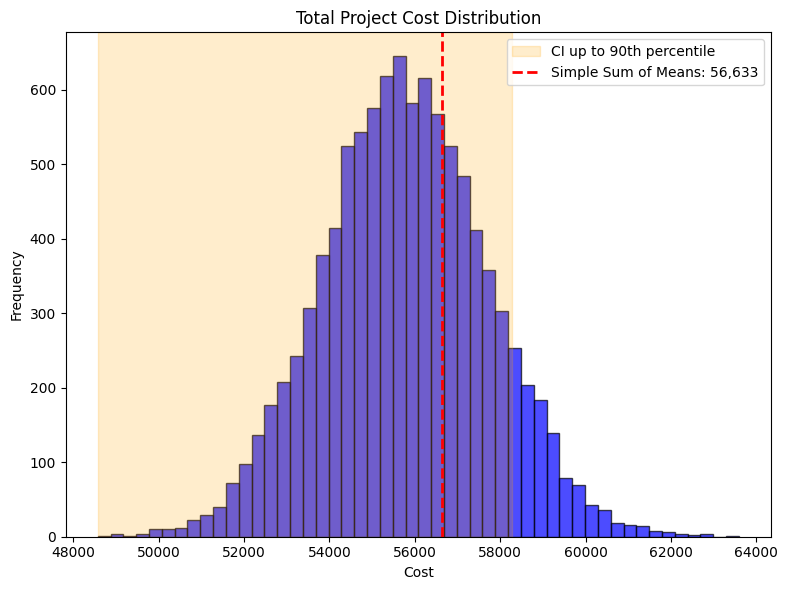

In [ ]:
# =========================================================
# 7) Graficar la distribución total con el IC al 90%
#    y la línea de la suma simple
# =========================================================
plot_total_distribution(
    total_costs=total_project_costs,
    confidence=0.90,
    simple_sum=simple_sum
)

# Example 2

In [13]:
# Semilla para reproducibilidad (opcional)
np.random.seed(123)

# Definir el número de simulaciones
n_simulations = 10000

# Lista de actividades con (Optimistic, Most Probable, Pessimistic)
activities = [
        {"name": "Activity 1",  "optimistic": 500, "most_probable": 1500, "pessimistic": 2500},
        {"name": "Activity 2",  "optimistic": 3000, "most_probable": 5000, "pessimistic": 8000},
        {"name": "Activity 3",  "optimistic": 2000, "most_probable": 3500, "pessimistic": 6000},
        {"name": "Activity 4",  "optimistic": 4000, "most_probable": 6000, "pessimistic": 8500},
        {"name": "Activity 5",  "optimistic": 3500, "most_probable": 5000, "pessimistic": 7500},
        {"name": "Activity 6",  "optimistic": 4500, "most_probable": 6500, "pessimistic": 9000},
        {"name": "Activity 7",  "optimistic": 2500, "most_probable": 4000, "pessimistic": 6000},
        {"name": "Activity 8",  "optimistic": 1500, "most_probable": 3000, "pessimistic": 4500},
        {"name": "Activity 9",  "optimistic": 600, "most_probable": 800, "pessimistic": 1000},
        {"name": "Activity 10", "optimistic": 550, "most_probable": 750, "pessimistic": 950},
        {"name": "Activity 11",  "optimistic": 500, "most_probable": 1500, "pessimistic": 2500},
        {"name": "Activity 12",  "optimistic": 500, "most_probable": 1500, "pessimistic": 2500},
        {"name": "Activity 13",  "optimistic": 500, "most_probable": 1500, "pessimistic": 2500},
        {"name": "Activity 14",  "optimistic": 500, "most_probable": 1500, "pessimistic": 2500},
        {"name": "Activity 15",  "optimistic": 65000, "most_probable": 85000, "pessimistic": 95000},
]

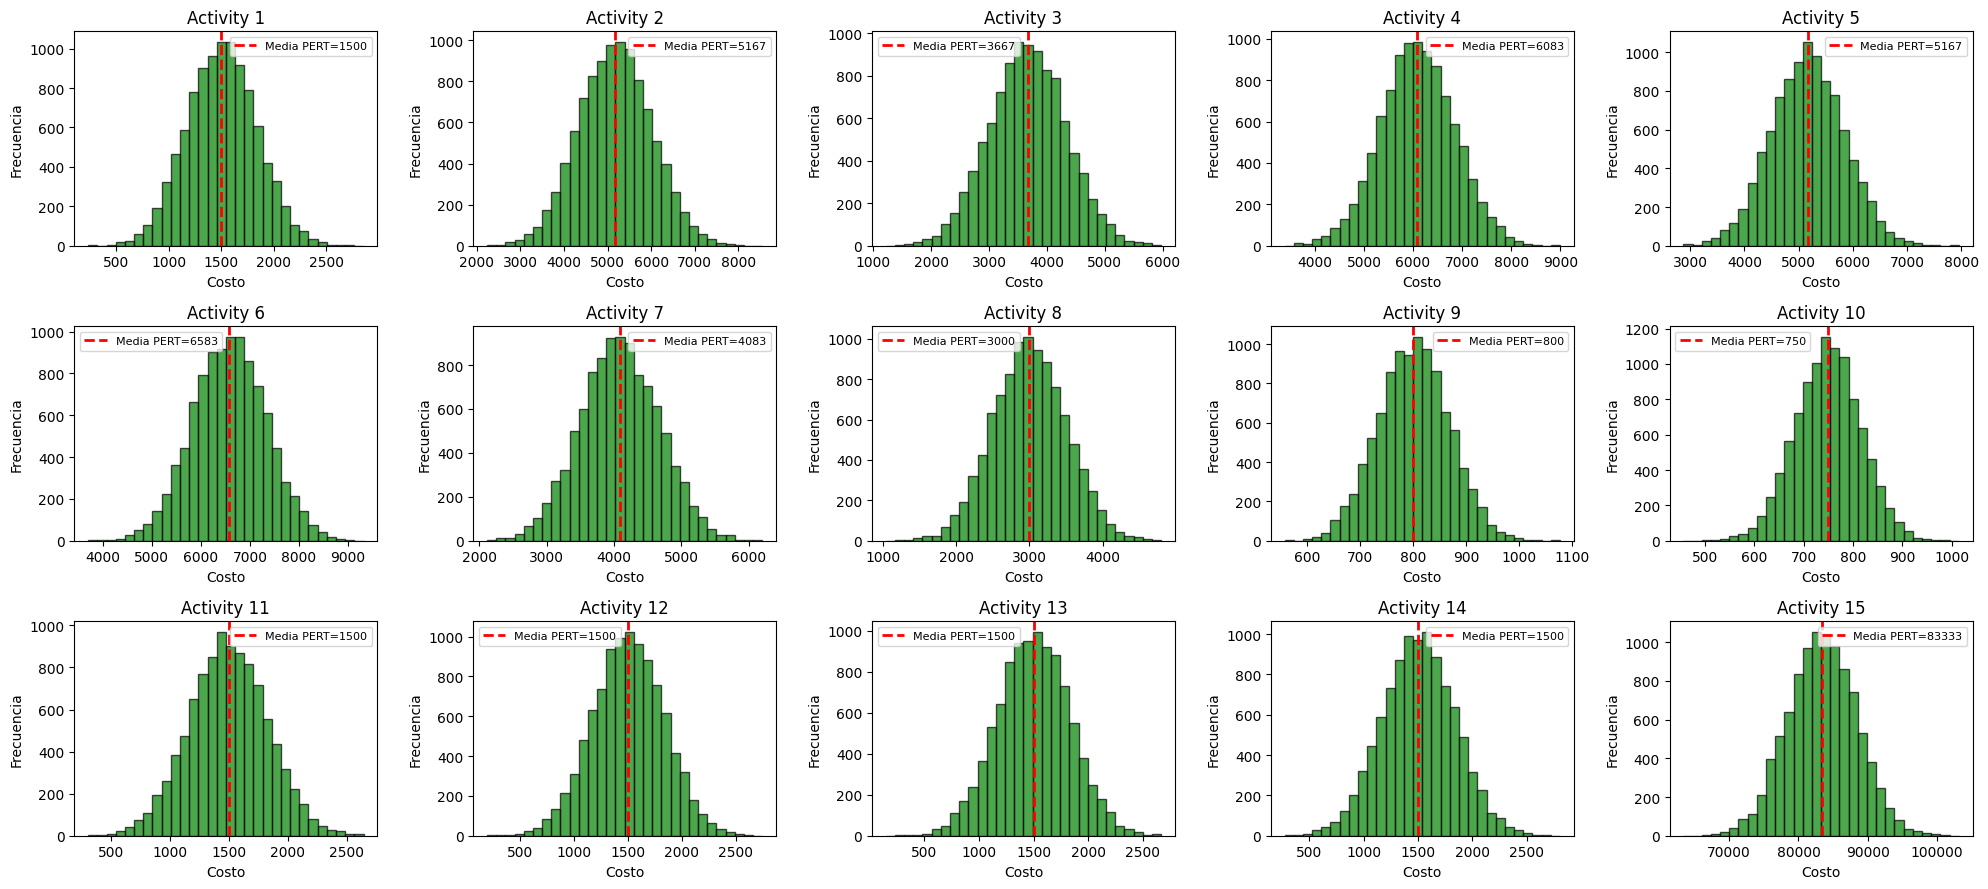

In [14]:
# =========================================================
# 1) Simular costos para cada actividad y guardar resultados
# =========================================================
all_activities_costs = []  # Aquí guardamos array de costos para cada actividad
for activity in activities:
    costs = pert_simulation(
        activity["optimistic"],
        activity["most_probable"],
        activity["pessimistic"],
        n_simulations
    )
    all_activities_costs.append(costs)
# =========================================================
# 2) Graficar la distribución de cada actividad (subplots)
# =========================================================
plot_activity_distributions(all_activities_costs, activities)

In [15]:
# =========================================================
# 3) Obtener la distribución de costos totales
#    sumando los costos de todas las actividades en cada corrida
# =========================================================
# Para cada simulación, sumamos los costos de todas las actividades:
total_project_costs = np.sum(all_activities_costs, axis=0)  # shape (n_simulations,)
# =========================================================
# 4) Calcular la "suma simple" de las medias PERT
#    (es decir, sin simulación, sólo la suma de los valores esperados)
# =========================================================
simple_sum = 0.0
for activity in activities:
    mean_pert = (activity["optimistic"]
                  + 4 * activity["most_probable"]
                  + activity["pessimistic"]) / 6
    simple_sum += mean_pert
# =========================================================
# 5) Calcular percentiles y contingencia
# =========================================================
p50 = calculate_percentile(total_project_costs, 50)
p90 = calculate_percentile(total_project_costs, 90)
p95 = calculate_percentile(total_project_costs, 95)
p10 = calculate_percentile(total_project_costs, 10)

# Por convención, a veces la "contingencia al 90%" se interpreta como el valor de P90
# (tal que hay 90% de probabilidad de no excederlo). Ajusta según tu criterio:
contingency_90 = p90

In [16]:
# =========================================================
# 6) Mostrar resultados numéricos
# =========================================================
print(f"\n================= RESULTADOS =================")
print(f"Suma simple (sólo medias PERT)         : ${simple_sum:,.2f}")
print(f"Mediana (P50) de la simulación total   : ${p50:,.2f}")
print(f"P10  de la simulación total            : ${p10:,.2f}")
print(f"P90  de la simulación total            : ${p90:,.2f}")
print(f"P90  de la simulación total            : ${p95:,.2f}")
print(f"Contingencia (usando P90 como referencia): ${contingency_90-simple_sum:,.2f}")
print(f"Contingencia (Porcentaje): {100*(contingency_90-simple_sum)/simple_sum:,.2f}%")
print("=============================================\n")


================= RESULTADOS =================
Suma simple (sólo medias PERT)         : $126,133.33
Mediana (P50) de la simulación total   : $126,193.17
P10  de la simulación total            : $119,444.59
P90  de la simulación total            : $132,998.40
P90  de la simulación total            : $134,904.04
Contingencia (usando P90 como referencia): $6,865.07
Contingencia (Porcentaje): 5.44%



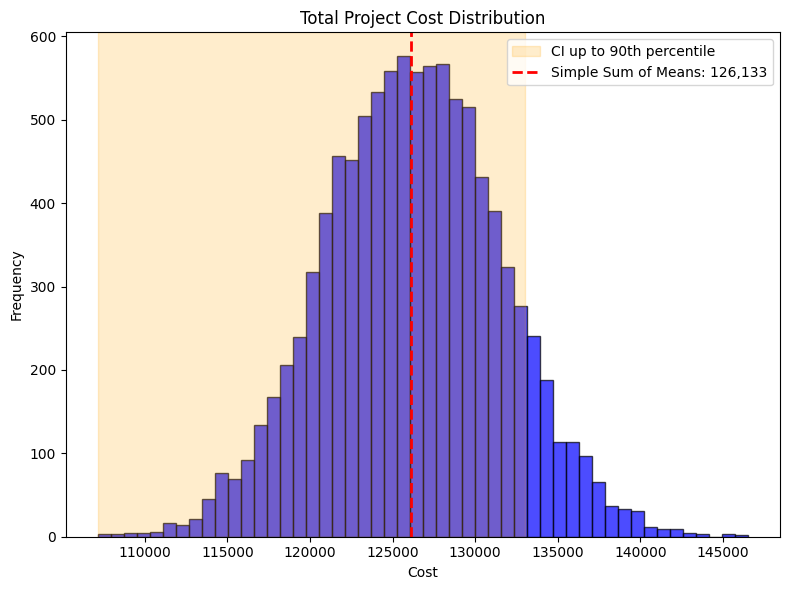

In [17]:
# =========================================================
# 7) Graficar la distribución total con el IC al 90%
#    y la línea de la suma simple
# =========================================================
plot_total_distribution(
    total_costs=total_project_costs,
    confidence=0.90,
    simple_sum=simple_sum
)

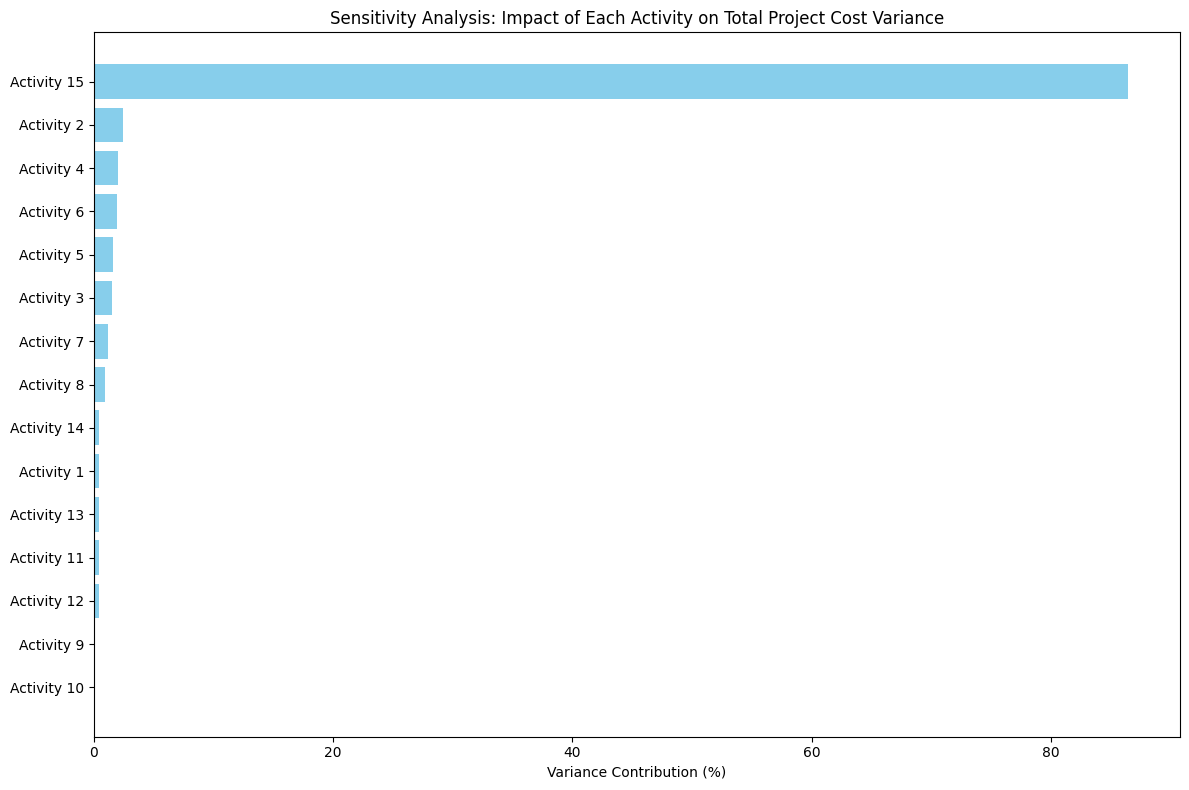

In [20]:
# =========================================================
# 8) Variance Contribution Analysis
# =========================================================
# Calculate variance of each activity
activity_variances = np.var(all_activities_costs, axis=1, ddof=1)  # shape (n_activities,)

# Calculate total project variance
total_variance = np.sum(activity_variances)  # Assuming independence

# Calculate contribution of each activity to total variance
variance_contributions = (activity_variances / total_variance) * 100  # percentage

# Pair each activity name with its variance contribution
activity_variance_contributions = list(zip([act["name"] for act in activities], variance_contributions))

# Sort activities by variance contribution (descending)
activity_variance_contributions.sort(key=lambda x: x[1], reverse=True)

# Separate names and contributions for plotting
sorted_names = [item[0] for item in activity_variance_contributions]
sorted_contributions = [item[1] for item in activity_variance_contributions]

# =========================================================
# 9) Plot Variance Contribution Analysis
# =========================================================
plt.figure(figsize=(12, 8))
plt.barh(sorted_names, sorted_contributions, color='skyblue')
plt.xlabel('Variance Contribution (%)')
plt.title('Sensitivity Analysis: Impact of Each Activity on Total Project Cost Variance')
plt.gca().invert_yaxis()  # Highest contribution on top
plt.tight_layout()
plt.show()